# Bike Sharing Demand — Regression with Temporal Validation

This case study develops a classical machine learning workflow for forecasting hourly bike-sharing demand using the UCI Bike Sharing dataset.

The target is `cnt`, the total number of bike rentals recorded during each hour. The modeling setup assumes that calendar information and weather conditions are available when a prediction is generated, while information that is only known after rentals occur must be excluded.

The analysis includes data-quality checks, leakage control, temporal validation, cyclic feature engineering, comparison of classical regression models, regularization, target transformation, Random Forest tuning, residual analysis, and model interpretation.

## 1. Setup

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile
from numbers import Integral

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.validation import check_is_fitted, validate_data

RANDOM_STATE = 42

## 2. Dataset

The hourly UCI Bike Sharing dataset contains 17,379 observations from 2011–2012.

The notebook downloads `hour.csv` from the official UCI archive when a local copy is not already available.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"

DATA_DIR = Path("data") / "bike_sharing"
ZIP_PATH = DATA_DIR / "bike_sharing_dataset.zip"
CSV_PATH = DATA_DIR / "hour.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)

if not CSV_PATH.exists():
    if not ZIP_PATH.exists():
        print("Downloading dataset from UCI...")
        urlretrieve(DATA_URL, ZIP_PATH)

    print("Extracting hour.csv...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extract("hour.csv", DATA_DIR)

df = pd.read_csv(CSV_PATH, parse_dates=["dteday"])

print(df.shape)
df.head()

Extracting hour.csv...
(17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 3. Data quality and leakage checks

The raw data contains no native missing values or exact duplicate rows. Each `(date, hour)` pair is also unique.

The target definition provides a direct leakage check:

\begin{equation}
\texttt{cnt} = \texttt{casual} + \texttt{registered}.
\end{equation}

This identity holds for every observation, so `casual` and `registered` cannot be used as predictors of `cnt`.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [4]:
print("Exact duplicate rows:", df.duplicated().sum())

duplicate_hour_count = (
    df.groupby(["dteday", "hr"])
      .size()
      .gt(1)
      .sum()
)

print("Duplicated (date, hour) combinations:", duplicate_hour_count)

Exact duplicate rows: 0
Duplicated (date, hour) combinations: 0


In [5]:
target_identity_violations = (
    df["casual"] + df["registered"] != df["cnt"]
).sum()

print("Rows violating cnt = casual + registered:", target_identity_violations)

Rows violating cnt = casual + registered: 0


## 4. Temporal train/test split

The observations are sorted chronologically and the final 20% is reserved as a future test set before the main exploratory analysis. The earlier 80% is used for model development.

In [6]:
sorted_df = (
    df.sort_values(["dteday", "hr"])
      .reset_index(drop=True)
)

n_data = len(sorted_df)
n_test = int(np.floor(n_data * 0.20))
train_test_cutoff_idx = n_data - n_test

train_df = sorted_df.iloc[:train_test_cutoff_idx].copy()
test_df = sorted_df.iloc[train_test_cutoff_idx:].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Training period:", train_df["dteday"].min(), "to", train_df["dteday"].max())
print("Test period:", test_df["dteday"].min(), "to", test_df["dteday"].max())

Training rows: 13904
Test rows: 3475
Training period: 2011-01-01 00:00:00 to 2012-08-07 00:00:00
Test period: 2012-08-07 00:00:00 to 2012-12-31 00:00:00


## 5. Exploratory analysis

The training target is strongly right-skewed with a long right tail.

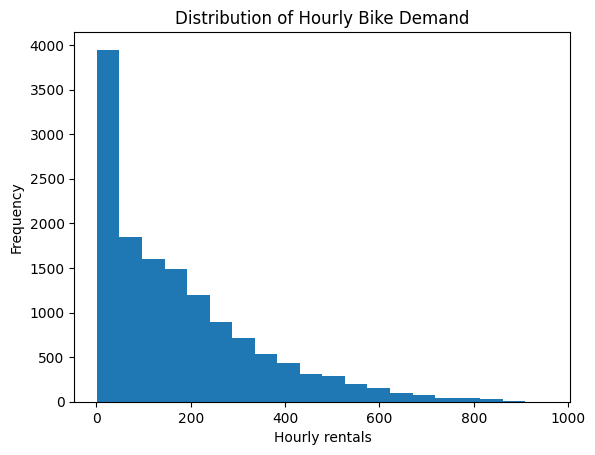

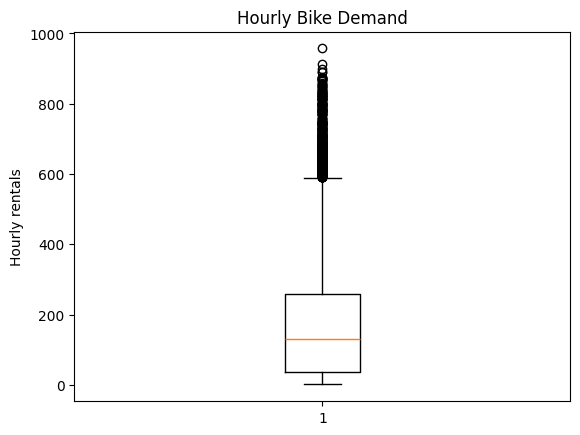

In [7]:
plt.hist(train_df["cnt"], bins=20)
plt.xlabel("Hourly rentals")
plt.ylabel("Frequency")
plt.title("Distribution of Hourly Bike Demand")
plt.show()

plt.boxplot(train_df["cnt"])
plt.ylabel("Hourly rentals")
plt.title("Hourly Bike Demand")
plt.show()

Average demand has a strong hourly structure. Working days show narrow commuting peaks in the morning and late afternoon, while non-working days show a broader daytime peak.

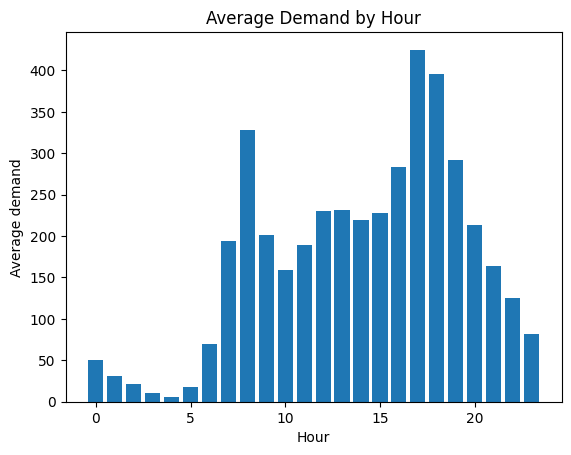

In [8]:
average_hourly_demand = (
    train_df.groupby("hr", as_index=False)
            .agg(average_demand=("cnt", "mean"))
)

plt.bar(
    average_hourly_demand["hr"],
    average_hourly_demand["average_demand"]
)
plt.xlabel("Hour")
plt.ylabel("Average demand")
plt.title("Average Demand by Hour")
plt.show()

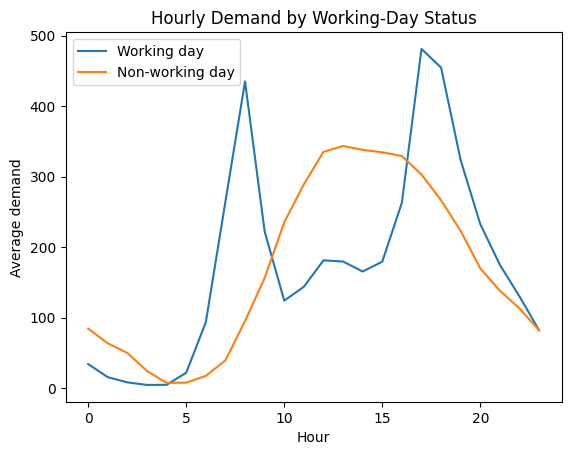

In [9]:
workingday_hourly = (
    train_df.loc[train_df["workingday"] == 1]
            .groupby("hr", as_index=False)
            .agg(average_demand=("cnt", "mean"))
)

nonworkingday_hourly = (
    train_df.loc[train_df["workingday"] == 0]
            .groupby("hr", as_index=False)
            .agg(average_demand=("cnt", "mean"))
)

plt.plot(
    workingday_hourly["hr"],
    workingday_hourly["average_demand"],
    label="Working day"
)
plt.plot(
    nonworkingday_hourly["hr"],
    nonworkingday_hourly["average_demand"],
    label="Non-working day"
)

plt.xlabel("Hour")
plt.ylabel("Average demand")
plt.title("Hourly Demand by Working-Day Status")
plt.legend()
plt.show()

Demand generally increases with temperature over much of the observed range, but the relationship is not purely linear and the response becomes more dispersed at higher demand levels.

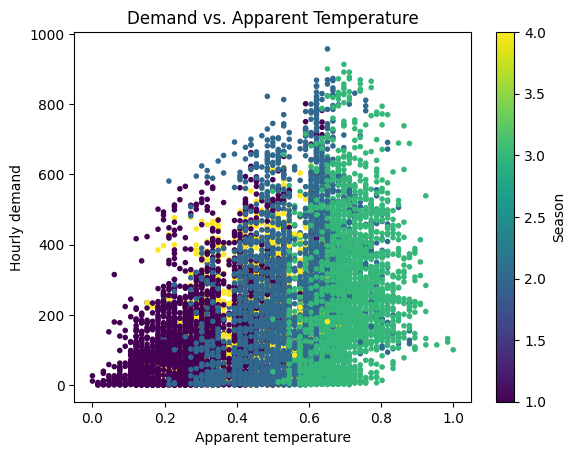

In [10]:
plt.scatter(
    train_df["atemp"],
    train_df["cnt"],
    marker=".",
    c=train_df["season"]
)
plt.colorbar(label="Season")
plt.xlabel("Apparent temperature")
plt.ylabel("Hourly demand")
plt.title("Demand vs. Apparent Temperature")
plt.show()

Season shifts the distribution of demand, although the seasonal distributions overlap substantially.

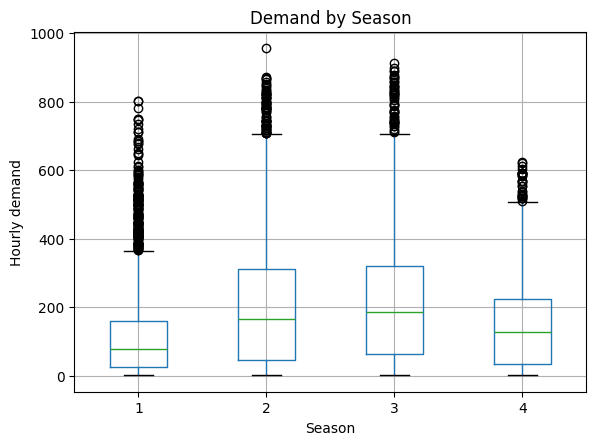

In [11]:
train_df.boxplot("cnt", by="season")
plt.suptitle("")
plt.title("Demand by Season")
plt.xlabel("Season")
plt.ylabel("Hourly demand")
plt.show()

`temp` and `atemp` are almost perfectly correlated in the training set. Because apparent temperature is derived from closely related weather information, `atemp` is excluded from the modeling features.

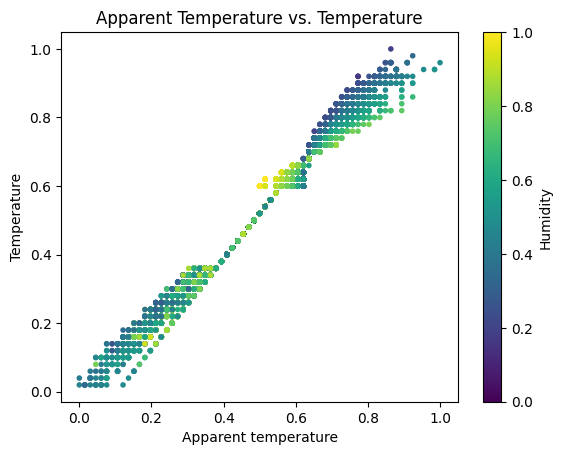

,temp,atemp
temp,1.000000,0.992385
atemp,0.992385,1.000000


In [12]:
plt.scatter(
    train_df["atemp"],
    train_df["temp"],
    marker=".",
    c=train_df["hum"]
)
plt.colorbar(label="Humidity")
plt.xlabel("Apparent temperature")
plt.ylabel("Temperature")
plt.title("Apparent Temperature vs. Temperature")
plt.show()

train_df[["temp", "atemp"]].corr()

Daily demand shows repeated seasonal structure and a higher overall level during 2012. A 30-day moving average is used only to visualize the longer-term pattern.

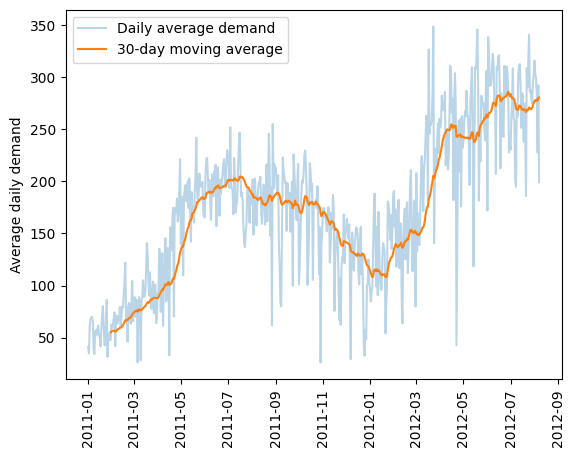

In [13]:
daily_average_demand = (
    train_df.groupby("dteday")["cnt"]
            .mean()
)

daily_average_demand_30d = (
    daily_average_demand
    .rolling(window=30)
    .mean()
)

plt.plot(
    daily_average_demand.index,
    daily_average_demand,
    alpha=0.3,
    label="Daily average demand"
)
plt.plot(
    daily_average_demand_30d.index,
    daily_average_demand_30d,
    label="30-day moving average"
)

plt.xticks(rotation="vertical")
plt.ylabel("Average daily demand")
plt.legend()
plt.show()

## 6. Modeling features

`instant` is excluded because it is a sequential identifier and an arbitrary proxy for time. `yr` is replaced by a continuous elapsed-time representation derived from `dteday`. `casual` and `registered` are excluded as direct components of the target.

Weather variables are retained under the assumption that weather information would be available when the forecast is generated. In production, using forecast weather rather than observed weather could introduce additional error that is not represented in this dataset.

In [14]:
keep_columns = [
    "dteday",
    "season",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "hum",
    "windspeed",
]

X_train = train_df[keep_columns].copy()
X_test = test_df[keep_columns].copy()

y_train = train_df["cnt"].copy()
y_test = test_df["cnt"].copy()

print(X_train.shape, X_test.shape)

(13904, 11) (3475, 11)


## 7. Feature engineering and preprocessing

Hour and month are periodic variables, so they are represented through Fourier components. The hourly transformer can also include interactions between the Fourier representation of hour and `workingday`.

The date is converted to elapsed years since January 1, 2011 to represent the temporal trend explicitly.

`season` and `weekday` are one-hot encoded. All transformations are kept inside the model pipeline so that fitted preprocessing is learned only from the training portion of each temporal fold.

In [15]:
class FourierTransformerWithInteractions(
    TransformerMixin,
    BaseEstimator
):
    """Generate Fourier features for a periodic variable."""

    def __init__(
        self,
        period,
        n_harmonics=1,
        include_interactions=False
    ):
        self.period = period
        self.n_harmonics = n_harmonics
        self.include_interactions = include_interactions

    def fit(self, X, y=None):
        X = validate_data(
            self,
            X,
            reset=True,
            ensure_2d=True,
            dtype=float
        )

        if self.period <= 0:
            raise ValueError("period must be greater than 0.")

        if (
            not isinstance(self.n_harmonics, Integral)
            or self.n_harmonics < 1
        ):
            raise ValueError(
                "n_harmonics must be a positive integer."
            )

        if not isinstance(self.include_interactions, bool):
            raise ValueError(
                "include_interactions must be a boolean."
            )

        if self.include_interactions and X.shape[1] < 2:
            raise ValueError(
                "include_interactions=True requires at least "
                "two input columns."
            )

        return self

    def transform(self, X):
        check_is_fitted(self)

        X = validate_data(
            self,
            X,
            reset=False,
            ensure_2d=True,
            dtype=float
        )

        periodic_variable = X[:, 0]

        if self.include_interactions:
            interaction_variables = X[:, 1:]

        features = []

        for k in range(1, self.n_harmonics + 1):
            angle = (
                2
                * np.pi
                * k
                * periodic_variable
                / self.period
            )

            sin_k = np.sin(angle)
            cos_k = np.cos(angle)

            features.extend([sin_k, cos_k])

            if self.include_interactions:
                for j in range(interaction_variables.shape[1]):
                    z = interaction_variables[:, j]
                    features.extend([
                        z * sin_k,
                        z * cos_k
                    ])

        return np.column_stack(features)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self)

        if input_features is None:
            if hasattr(self, "feature_names_in_"):
                input_features = self.feature_names_in_
            else:
                input_features = np.array([
                    f"x{i}" for i in range(self.n_features_in_)
                ])

        input_features = np.asarray(input_features, dtype=object)
        periodic_name = input_features[0]

        if self.include_interactions:
            interaction_names = input_features[1:]

        output_features = []

        for k in range(1, self.n_harmonics + 1):
            sin_name = f"{periodic_name}_sin_{k}"
            cos_name = f"{periodic_name}_cos_{k}"

            output_features.extend([sin_name, cos_name])

            if self.include_interactions:
                for interaction_name in interaction_names:
                    output_features.extend([
                        f"{interaction_name}_x_{sin_name}",
                        f"{interaction_name}_x_{cos_name}"
                    ])

        return np.asarray(output_features, dtype=object)


class YearsSinceReferenceDate(
    TransformerMixin,
    BaseEstimator
):
    """Convert one datetime column into elapsed years."""

    def __init__(self, reference_date):
        self.reference_date = reference_date

    def fit(self, X, y=None):
        X = validate_data(
            self,
            X,
            reset=True,
            dtype="datetime64[ns]"
        )

        if X.shape[1] != 1:
            raise ValueError(
                "YearsSinceReferenceDate expects exactly "
                "one datetime column."
            )

        try:
            self.timestamp_ = pd.Timestamp(self.reference_date)
        except Exception as exc:
            raise ValueError("Invalid date format.") from exc

        if pd.isna(self.timestamp_):
            raise ValueError("reference_date cannot be NaT.")

        self.reference_datetime64_ = (
            self.timestamp_
            .to_datetime64()
            .astype("datetime64[ns]")
        )

        return self

    def transform(self, X):
        check_is_fitted(self, "reference_datetime64_")

        X = validate_data(
            self,
            X,
            reset=False,
            dtype="datetime64[ns]"
        )

        dates = X[:, 0]
        delta = dates - self.reference_datetime64_
        days = delta / np.timedelta64(1, "D")
        years = days / 365.25

        return years.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "reference_datetime64_")

        if input_features is None:
            if hasattr(self, "feature_names_in_"):
                input_features = self.feature_names_in_
            else:
                input_features = np.array(["x0"])

        input_features = np.asarray(input_features, dtype=object)

        if len(input_features) != 1:
            raise ValueError(
                "YearsSinceReferenceDate expects exactly "
                "one input feature name."
            )

        return np.array(
            [f"{input_features[0]}_years_since_reference"],
            dtype=object
        )

In [16]:
preprocessing = ColumnTransformer(
    [
        (
            "cat_encoder",
            OneHotEncoder(handle_unknown="ignore"),
            ["season", "weekday"]
        ),
        (
            "hr_fourier",
            FourierTransformerWithInteractions(
                period=24,
                n_harmonics=4,
                include_interactions=True
            ),
            ["hr", "workingday"]
        ),
        (
            "mnth_fourier",
            FourierTransformerWithInteractions(
                period=12
            ),
            ["mnth"]
        ),
        (
            "years_since_reference",
            YearsSinceReferenceDate("01/01/2011"),
            ["dteday"]
        ),
        (
            "workingday_passthrough",
            "passthrough",
            ["workingday"]
        ),
    ],
    remainder="passthrough"
)

## 8. Temporal validation and metrics

Model selection uses expanding-window temporal validation. Validation observations always occur after the observations used to train the corresponding fold.

Performance is evaluated with MAE, RMSE, and $R^2$.

In [17]:
def time_split_oof_predict(model, cv, X, y):
    oof_pred = np.full(len(X), np.nan)
    all_val_idx = []

    for train_idx, val_idx in cv.split(X):
        fold_model = clone(model)

        fold_model.fit(
            X.iloc[train_idx],
            y.iloc[train_idx]
        )

        oof_pred[val_idx] = fold_model.predict(
            X.iloc[val_idx]
        )

        all_val_idx.extend(val_idx)

    return oof_pred, np.array(all_val_idx)


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

In [18]:
n_train_2012 = (
    X_train["dteday"]
    .ge(pd.Timestamp("2012-01-01"))
    .sum()
)

cv = TimeSeriesSplit(
    n_splits=5,
    test_size=n_train_2012 // 5
)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train), 1):
    print(
        f"Fold {fold}:",
        X_train.iloc[train_idx]["dteday"].min(),
        "->",
        X_train.iloc[train_idx]["dteday"].max(),
        "| validation:",
        X_train.iloc[val_idx]["dteday"].min(),
        "->",
        X_train.iloc[val_idx]["dteday"].max(),
    )

Fold 1: 2011-01-01 00:00:00 -> 2012-01-01 00:00:00 | validation: 2012-01-01 00:00:00 -> 2012-02-14 00:00:00
Fold 2: 2011-01-01 00:00:00 -> 2012-02-14 00:00:00 | validation: 2012-02-14 00:00:00 -> 2012-03-29 00:00:00
Fold 3: 2011-01-01 00:00:00 -> 2012-03-29 00:00:00 | validation: 2012-03-29 00:00:00 -> 2012-05-11 00:00:00
Fold 4: 2011-01-01 00:00:00 -> 2012-05-11 00:00:00 | validation: 2012-05-11 00:00:00 -> 2012-06-24 00:00:00
Fold 5: 2011-01-01 00:00:00 -> 2012-06-24 00:00:00 | validation: 2012-06-24 00:00:00 -> 2012-08-07 00:00:00


## 9. Baseline

In [19]:
baseline_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", DummyRegressor())
])

baseline_oof_pred, baseline_val_idx = time_split_oof_predict(
    baseline_model,
    cv,
    X_train,
    y_train
)

baseline_metrics = regression_metrics(
    y_train.iloc[baseline_val_idx],
    baseline_oof_pred[baseline_val_idx]
)

baseline_metrics

{'MAE': 158.20064744111096,
 'RMSE': 211.97360591314387,
 'R2': -0.11950674605883749}

## 10. Model comparison

In [20]:
linear_regression_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", LinearRegression())
])

linear_oof_pred, linear_val_idx = time_split_oof_predict(
    linear_regression_model,
    cv,
    X_train,
    y_train
)

linear_metrics = regression_metrics(
    y_train.iloc[linear_val_idx],
    linear_oof_pred[linear_val_idx]
)

linear_metrics

{'MAE': 81.21497514848444, 'RMSE': 109.7495543176338, 'R2': 0.6998981517900263}

In [21]:
ridge_regression_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", Ridge())
])

ridge_oof_pred, ridge_val_idx = time_split_oof_predict(
    ridge_regression_model,
    cv,
    X_train,
    y_train
)

ridge_metrics = regression_metrics(
    y_train.iloc[ridge_val_idx],
    ridge_oof_pred[ridge_val_idx]
)

ridge_metrics

{'MAE': 81.23070536761095,
 'RMSE': 109.77579143889078,
 'R2': 0.6997546477949474}

In [22]:
elastic_net_regression_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", ElasticNet())
])

elastic_oof_pred, elastic_val_idx = time_split_oof_predict(
    elastic_net_regression_model,
    cv,
    X_train,
    y_train
)

elastic_metrics = regression_metrics(
    y_train.iloc[elastic_val_idx],
    elastic_oof_pred[elastic_val_idx]
)

elastic_metrics

{'MAE': 111.55403364636848,
 'RMSE': 160.70340458567566,
 'R2': 0.3565522379172953}

In [23]:
decision_tree_regression_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ))
])

tree_oof_pred, tree_val_idx = time_split_oof_predict(
    decision_tree_regression_model,
    cv,
    X_train,
    y_train
)

tree_metrics = regression_metrics(
    y_train.iloc[tree_val_idx],
    tree_oof_pred[tree_val_idx]
)

tree_metrics

{'MAE': 55.543101807802095,
 'RMSE': 88.06283869212768,
 'R2': 0.8067815913043833}

In [24]:
random_forest_regression_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

forest_oof_pred, forest_val_idx = time_split_oof_predict(
    random_forest_regression_model,
    cv,
    X_train,
    y_train
)

forest_metrics = regression_metrics(
    y_train.iloc[forest_val_idx],
    forest_oof_pred[forest_val_idx]
)

forest_metrics

{'MAE': 45.202812559467176,
 'RMSE': 72.85986027724326,
 'R2': 0.8677365619241948}

In [25]:
hist_gradient_boost_regression_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", HistGradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

hist_oof_pred, hist_val_idx = time_split_oof_predict(
    hist_gradient_boost_regression_model,
    cv,
    X_train,
    y_train
)

hist_metrics = regression_metrics(
    y_train.iloc[hist_val_idx],
    hist_oof_pred[hist_val_idx]
)

hist_metrics

{'MAE': 42.00636237688509, 'RMSE': 66.54292712750842, 'R2': 0.8896767768764208}

In [26]:
model_comparison = pd.DataFrame(
    {
        "Dummy": baseline_metrics,
        "Linear Regression": linear_metrics,
        "Ridge": ridge_metrics,
        "Elastic Net": elastic_metrics,
        "Decision Tree": tree_metrics,
        "Random Forest": forest_metrics,
        "HistGradientBoosting": hist_metrics,
    }
).T

model_comparison

,MAE,RMSE,R2
Dummy,158.200647,211.973606,-0.119507
Linear Regression,81.214975,109.749554,0.699898
Ridge,81.230705,109.775791,0.699755
Elastic Net,111.554034,160.703405,0.356552
Decision Tree,55.543102,88.062839,0.806782
Random Forest,45.202813,72.859860,0.867737
HistGradientBoosting,42.006362,66.542927,0.889677


The nonlinear tree-based models outperform the linear models under temporal validation. Histogram Gradient Boosting produces the strongest untuned validation metrics.

Random Forest is selected for the final tuning stage for **pedagogical reasons**, in order to explore a bagging-based ensemble, tree complexity, Fourier hyperparameters, and tree-based feature interpretation in more depth.

## 11. Ridge regularization

In [27]:
ridge_regression_model_params = {
    "regressor__alpha": np.logspace(-3, 4, 8)
}

ridge_search = GridSearchCV(
    clone(ridge_regression_model),
    ridge_regression_model_params,
    scoring=[
        "neg_root_mean_squared_error",
        "neg_mean_absolute_error"
    ],
    cv=cv,
    refit="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

ridge_best_idx = ridge_search.best_index_

ridge_mean_rmse = -ridge_search.cv_results_[
    "mean_test_neg_root_mean_squared_error"
][ridge_best_idx]

ridge_std_rmse = ridge_search.cv_results_[
    "std_test_neg_root_mean_squared_error"
][ridge_best_idx]

print("Best alpha:", ridge_search.best_params_["regressor__alpha"])
print(f"RMSE: {ridge_mean_rmse:.3f} ± {ridge_std_rmse:.3f}")

for fold in range(cv.n_splits):
    fold_rmse = -ridge_search.cv_results_[
        f"split{fold}_test_neg_root_mean_squared_error"
    ][ridge_best_idx]

    print(f"Fold {fold + 1}: {fold_rmse:.3f}")

Best alpha: 0.001
RMSE: 108.615 ± 15.743
Fold 1: 80.066
Fold 2: 102.978
Fold 3: 119.637
Fold 4: 121.361
Fold 5: 119.030


## 12. Log-transformed target

Linear Regression is also trained with a `log1p` target transformation and transformed back with `expm1`.

In [28]:
transformed_linear_regression_model = TransformedTargetRegressor(
    regressor=clone(linear_regression_model),
    func=np.log1p,
    inverse_func=np.expm1
)

transformed_linear_oof_pred, transformed_linear_val_idx = (
    time_split_oof_predict(
        transformed_linear_regression_model,
        cv,
        X_train,
        y_train
    )
)

transformed_linear_metrics = regression_metrics(
    y_train.iloc[transformed_linear_val_idx],
    transformed_linear_oof_pred[transformed_linear_val_idx]
)

pd.DataFrame(
    {
        "Linear Regression": linear_metrics,
        "Linear Regression + log1p target": transformed_linear_metrics,
    }
).T

,MAE,RMSE,R2
Linear Regression,81.214975,109.749554,0.699898
Linear Regression + log1p target,67.577045,110.946417,0.693317


The target transformation reduces MAE but does not improve RMSE, showing that the change in target scale alters which kinds of prediction errors are emphasized.

## 13. Random Forest hyperparameter tuning

In [29]:
final_regressor_grid = {
    "preprocessing__hr_fourier__include_interactions": [False],
    "preprocessing__hr_fourier__n_harmonics": [1, 3, 6],
    "regressor__n_estimators": [300, 500],
    "regressor__max_depth": [10, 20, None],
    "regressor__min_samples_leaf": [1, 10, 20],
    "regressor__max_features": ["sqrt", 0.5, 1.0],
}

final_regressor_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", RandomForestRegressor(
        random_state=RANDOM_STATE
    ))
])

final_search = GridSearchCV(
    final_regressor_pipeline,
    final_regressor_grid,
    scoring=[
        "neg_root_mean_squared_error",
        "neg_mean_absolute_error"
    ],
    cv=cv,
    refit="neg_root_mean_squared_error",
    n_jobs=-1
)

final_search.fit(X_train, y_train)

final_best_idx = final_search.best_index_

final_mean_rmse = -final_search.cv_results_[
    "mean_test_neg_root_mean_squared_error"
][final_best_idx]

final_std_rmse = final_search.cv_results_[
    "std_test_neg_root_mean_squared_error"
][final_best_idx]

final_mean_mae = -final_search.cv_results_[
    "mean_test_neg_mean_absolute_error"
][final_best_idx]

final_std_mae = final_search.cv_results_[
    "std_test_neg_mean_absolute_error"
][final_best_idx]

print(f"RMSE: {final_mean_rmse:.3f} ± {final_std_rmse:.3f}")
print(f"MAE: {final_mean_mae:.3f} ± {final_std_mae:.3f}")
print()

for param, value in final_search.best_params_.items():
    print(f"{param}: {value}")

print()
for fold in range(cv.n_splits):
    fold_rmse = -final_search.cv_results_[
        f"split{fold}_test_neg_root_mean_squared_error"
    ][final_best_idx]

    print(f"Fold {fold + 1}: {fold_rmse:.3f}")

final_model = final_search.best_estimator_

RMSE: 72.893 ± 7.832
MAE: 45.520 ± 4.935

preprocessing__hr_fourier__include_interactions: False
preprocessing__hr_fourier__n_harmonics: 3
regressor__max_depth: 20
regressor__max_features: 1.0
regressor__min_samples_leaf: 1
regressor__n_estimators: 300

Fold 1: 82.298
Fold 2: 79.534
Fold 3: 61.866
Fold 4: 65.914
Fold 5: 74.853


## 14. Final evaluation on the future test period

In [30]:
y_pred = final_model.predict(X_test)
residuals = y_test.to_numpy() - y_pred

test_metrics = regression_metrics(y_test, y_pred)
test_metrics

{'MAE': 46.44718421007233, 'RMSE': 74.0948600979298, 'R2': 0.8870992457114145}

## 15. Residual analysis

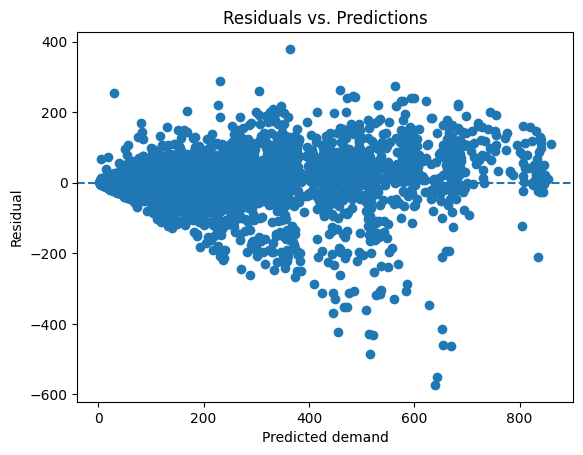

,mean,std,count
pred_bin,,,
"(2.992, 13.67]",0.139898,5.431156,348
"(13.67, 41.887]",-3.045738,18.528623,347
"(41.887, 102.683]",3.816077,33.757961,348
"(102.683, 158.319]",-2.482990,51.160859,347
"(158.319, 211.958]",3.369470,54.577819,348
"(211.958, 265.618]",0.198154,64.594349,347
"(265.618, 319.995]",7.436931,74.197966,347
"(319.995, 418.447]",7.685732,98.458213,348
"(418.447, 533.721]",-4.256309,116.385155,347


In [31]:
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted demand")
plt.ylabel("Residual")
plt.title("Residuals vs. Predictions")
plt.show()

residual_frame = pd.DataFrame({
    "y_pred": y_pred,
    "residual": residuals,
})

residual_frame["pred_bin"] = pd.qcut(
    residual_frame["y_pred"],
    10
)

residual_frame.groupby(
    "pred_bin",
    observed=True
)["residual"].agg(
    ["mean", "std", "count"]
)

Residual variance increases substantially with predicted demand. Most prediction bins remain approximately centered near zero, while the highest prediction range shows a positive mean residual, indicating underestimation at the upper end of demand.

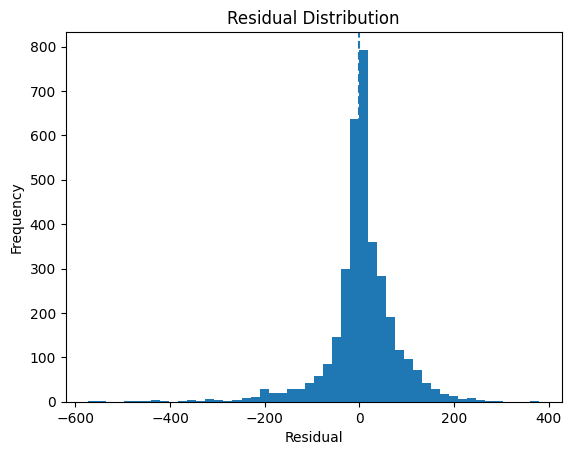

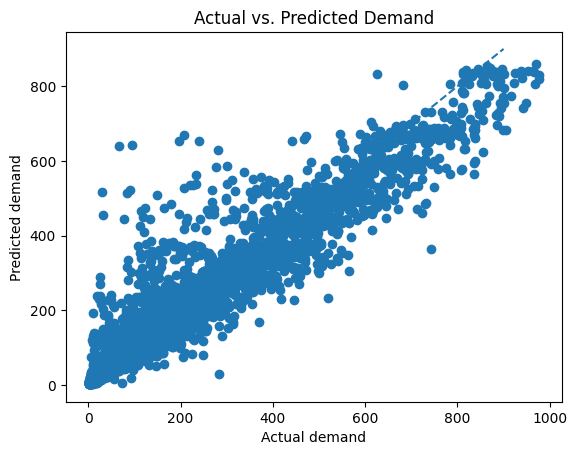

In [32]:
plt.hist(residuals, bins=50)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

plt.scatter(y_test, y_pred)
plt.plot([0, 900], [0, 900], linestyle="--")
plt.xlabel("Actual demand")
plt.ylabel("Predicted demand")
plt.title("Actual vs. Predicted Demand")
plt.show()

## 16. Error analysis

In [33]:
analysis = X_test.copy()

analysis["y_true"] = y_test.to_numpy()
analysis["y_pred"] = y_pred
analysis["residual"] = analysis["y_true"] - analysis["y_pred"]
analysis["abs_error"] = np.abs(analysis["residual"])

error_columns = [
    "mnth",
    "hr",
    "workingday",
    "weathersit",
    "y_true",
    "y_pred",
    "residual",
    "abs_error",
]

analysis.nlargest(20, "abs_error")[error_columns]

,mnth,hr,workingday,weathersit,y_true,y_pred,residual,abs_error
17196,12,8,1,1,66,638.870000,-572.870000,572.870000
16454,11,8,1,1,94,643.773333,-549.773333,549.773333
17195,12,7,1,1,30,515.595000,-485.595000,485.595000
17267,12,8,1,1,208,669.510000,-461.510000,461.510000
17363,12,8,1,1,196,654.586667,-458.586667,458.586667
17266,12,7,1,1,90,521.190833,-431.190833,431.190833
17362,12,7,1,1,85,513.026111,-428.026111,428.026111
17243,12,8,1,3,31,455.160000,-424.160000,424.160000
17291,12,8,1,2,239,652.460000,-413.460000,413.460000
15470,10,19,1,1,743,363.710000,379.290000,379.290000


The largest absolute errors are dominated by severe overestimation cases on working days around the morning peak, especially late in the year.

In [34]:
weather_error_analysis = (
    analysis.groupby("weathersit", as_index=False)
            .agg(
                n_count=("residual", "count"),
                residual_mean=("residual", "mean"),
                mae=("abs_error", "mean"),
            )
)

weather_error_analysis

,weathersit,n_count,residual_mean,mae
0,1,2162,9.686569,43.482014
1,2,1075,1.348173,46.473667
2,3,238,-25.456455,73.263273


Performance deteriorates for `weathersit = 3`, where MAE is substantially larger than for the two more common weather categories. The negative mean residual in that segment indicates overestimation.

## 17. Model interpretation

In [35]:
impurity_importance = (
    pd.DataFrame({
        "Feature": final_model[:-1].get_feature_names_out(),
        "Importance": final_model[-1].feature_importances_,
    })
    .sort_values("Importance", ascending=False)
)

impurity_importance.head(15)

,Feature,Importance
11,hr_fourier__hr_sin_1,0.286887
12,hr_fourier__hr_cos_1,0.200541
19,years_since_reference__dteday_years_since_refe...,0.149485
23,remainder__temp,0.120925
20,workingday_passthrough__workingday,0.077631
13,hr_fourier__hr_sin_2,0.031069
16,hr_fourier__hr_cos_3,0.030437
24,remainder__hum,0.029624
22,remainder__weathersit,0.015949
14,hr_fourier__hr_cos_2,0.014494


In [36]:
perm_imp = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

permutation_importance_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": perm_imp.importances_mean,
        "Std": perm_imp.importances_std,
    })
    .sort_values("Importance", ascending=False)
)

permutation_importance_df

,Feature,Importance,Std
3,hr,1.429979,0.031505
6,workingday,0.349306,0.009486
8,temp,0.172446,0.006363
9,hum,0.050626,0.002916
7,weathersit,0.019897,0.001456
5,weekday,0.016230,0.001028
10,windspeed,0.002050,0.000575
2,mnth,0.000562,0.000111
1,season,0.000519,0.000070
4,holiday,0.000500,0.000171


The Random Forest relies strongly on the Fourier representation of hour. Permutation importance on the raw input columns also identifies hour of day as the dominant predictor, followed by working-day status and temperature.

The derived temporal trend receives substantial impurity-based importance, while permutation of the raw date on the held-out test set produces little change in performance. These two importance views are reported separately and are not interpreted causally.

## 18. Summary

- The forecasting setup excludes direct target leakage from `casual` and `registered`.
- The final 20% of observations is held out chronologically as a future test period.
- Model development uses expanding-window temporal validation.
- Hour and month are represented with Fourier features, while date is converted to a continuous elapsed-time feature.
- Tree-based nonlinear models outperform the linear alternatives under temporal validation.
- Histogram Gradient Boosting has the strongest untuned validation performance.
- Random Forest is selected for the tuning and interpretation stages for pedagogical exploration.
- Final evaluation uses MAE, RMSE, $R^2$, residual diagnostics, segmented error analysis, and feature importance.